## Triggered MUA

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums

In [5]:
from spyglass.shijiegu.Analysis_SGU import MUA
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day, return_triggered_mua

In [94]:
def figure_mua_data(animal, day, encoding_set, classifier_param_name):
    parameters = {"proportion": 0.1,
                  "delta_t_minus":5, "delta_t_plus":5,
                  "max_flag":0, "segment_only": False,
                  "control": False}
    
    
    loaded_data = load_triggered_position_decode_day(animal, day, encoding_set, classifier_param_name, **parameters)
    positions = loaded_data["triggered_positions"]
    positions_abs = loaded_data["triggered_positions_baseoff"]
    trial_infos = loaded_data["triggered_trial_info"]
    mua, mean, sd, t0 = return_triggered_mua(positions, positions_abs, trial_infos)
    
    # control day
    parameters["control"] = True
    loaded_data_control = load_triggered_position_decode_day(animal, day, encoding_set, classifier_param_name, **parameters)
    positions_control = loaded_data_control["triggered_positions"]
    positions_abs_control = loaded_data_control["triggered_positions_baseoff"]
    trial_infos_control = loaded_data_control["triggered_trial_info"]
    mua_control, mean_control, sd_control, t0_control = return_triggered_mua(positions_control, positions_abs_control, trial_infos_control)

    return mua, mean, sd, t0, mua_control, mean_control, sd_control, t0_control
    
def figure_mua_plot(mua, mean, sd, t0, mua_control, mean_control, sd_control, t0_control):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3),sharex=False)

    bins = np.linspace(-2.1,2.1,100)
    
    zscore_all = []
    zscore_control_all = []
    for ind in range(len(mua)):
        time = np.array(mua[ind].time) - t0[ind]
        zscored = (np.array(mua[ind].mua) - mean[ind]) / sd[ind]
    
        bin_indices = np.digitize(time, bins)
        binned_zscore = [np.mean(zscored[bin_indices == bin_ind]) for bin_ind in range(len(bins))]
        zscore_all.append(binned_zscore)
        
        ax1.plot(time, zscored, linewidth = 1, alpha = 0.1, color = 'C0')
        ax2.plot(time, zscored, linewidth = 1, alpha = 0.1, color = 'C0')
    
    # control data
    for ind in range(len(mua_control)):
        time = np.array(mua_control[ind].time) - t0_control[ind]
        zscored = (np.array(mua_control[ind].mua) - mean_control[ind]) / sd_control[ind]

        bin_indices = np.digitize(time, bins)
        binned_zscore = [np.nanmean(zscored[bin_indices == bin_ind]) for bin_ind in range(len(bins))]
        zscore_control_all.append(binned_zscore)
        
        ax1.plot(time, zscored, linewidth = 1, alpha = 0.1, color = 'C1')
        ax2.plot(time, zscored, linewidth = 1, alpha = 0.1, color = 'C1')

    zscore_all = np.array(zscore_all)
    
    mu = np.nanmean(zscore_all, axis = 0)
    sigma = np.nanstd(zscore_all, axis = 0)
    zscore_control_all = np.array(zscore_control_all)
    mu_control = np.nanmean(zscore_control_all, axis = 0)
    sigma_control = np.nanstd(zscore_control_all, axis = 0)

    
    ax1.fill_between(bins, mu - sigma, mu + sigma, alpha = 0.7, color = 'C0', label = "CoM trials")
    ax1.fill_between(bins, mu_control - sigma_control, mu_control + sigma_control, alpha = 0.5, color = 'C1', label = "nearby trials")

    ax2.fill_between(bins, mu - sigma, mu + sigma, alpha = 0.7, color = 'C0', label = "CoM trials")
    ax2.fill_between(bins, mu_control - sigma_control, mu_control + sigma_control, alpha = 0.5, color = 'C1', label = "nearby trials")

    ax1.legend()
    ax2.legend()
    
    ax1.set_xlim([-0.2,0.2])
    ax1.set_ylim([-1,5])
    
    
    ax1.set_title(f"{animal}{day} MUA")
    ax1.set_xlabel("time (seconds), relative to stopping")
    ax1.set_ylabel("MUA (zscored)")

    ax2.set_xlim([-1,1])
    ax2.set_ylim([-1,5])
    
    ax2.set_title(f"{animal}{day} MUA")
    ax2.set_xlabel("time (seconds), relative to stopping")
    ax2.set_ylabel("MUA (zscored)")
    
    
    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure2/MUA_{animal}_{day}"
    plt.savefig(file_path + ".pdf")
    plt.savefig(file_path + ".png") 

    return 1

In [87]:
encoding_sets = {}
classifier_param_names = {}
days = {}

# load triggered_position_decode
animal = "Molly"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20220418'

animal = "Eliot"
encoding_sets[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20221021'

animal = "Klein"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20231107'

animal = "Julio"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20230803'

animal = "Lewis"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20240105'

In [88]:
### data making

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'

for animal in days.keys():
    day = days[animal]
    encoding_set = encoding_sets[animal]
    classifier_param_name = classifier_param_names[animal]

    data = {}
    (data["mua"], data["mean"], data["sd"], data["t0"],
     data["mua_control"], data["mean_control"], data["sd_control"], data["t0_control"]) = figure_mua_data(
        animal, day, encoding_set, classifier_param_name)

    file_path = f"{output_folder}/{animal[:5]}_mua.pickle"
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")
    

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220418_p0.1_tm5_tp5_maxflag0_controlFalse_allposterior.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220418_p0.1_tm5_tp5_maxflag0_controlTrue_allposterior.pkl':
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/Molly_mua.pickle
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/eliot_triggered_position_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221021_p0.1_tm5_tp5_maxflag0_controlFalse_allposterior.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/eliot_triggered_position_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221021_p0.1_tm5_tp5_maxflag0_controlTrue_allposterior.pkl':
Data successfully pickled and saved to /stelmo/

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Molly_mua.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Eliot_mua.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Klein_mua.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Lewis_mua.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Julio_mua.pickle


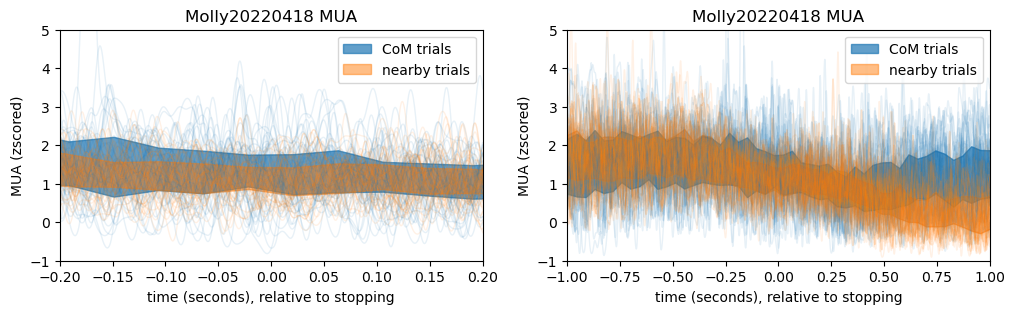

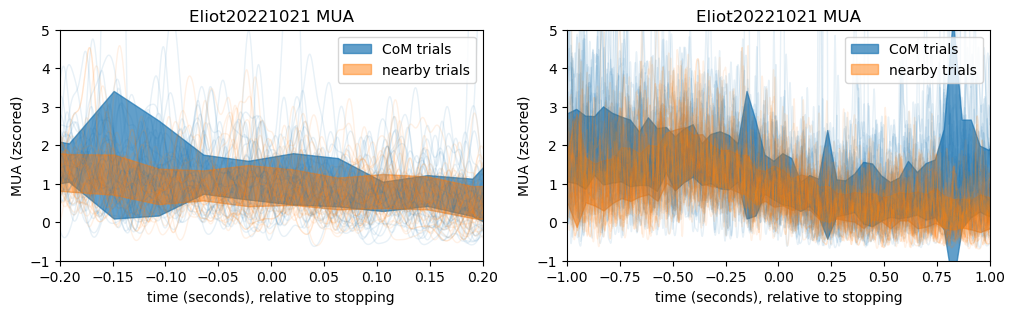

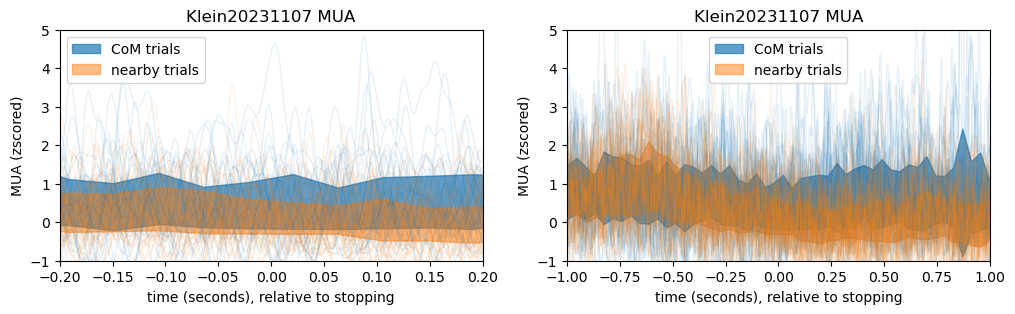

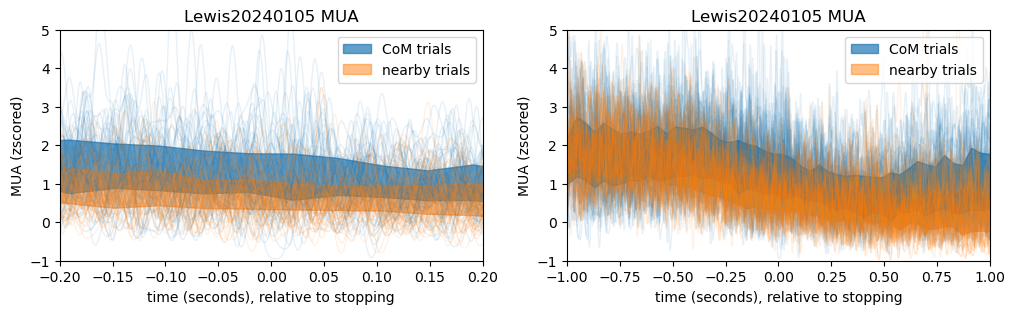

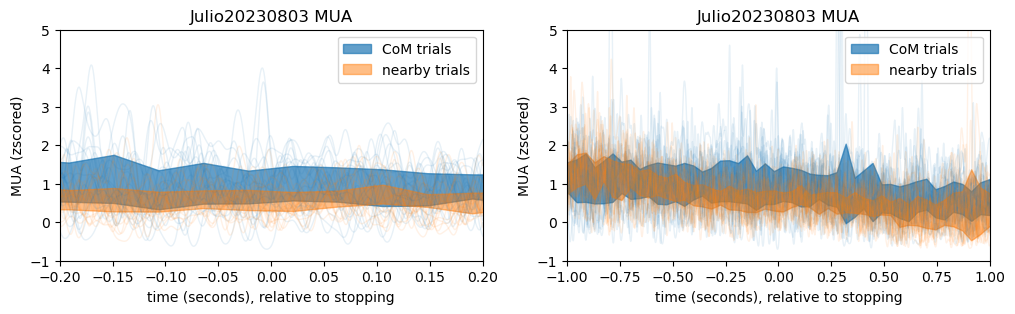

In [95]:
### data plotting
for animal in ["Molly","Eliot","Klein","Lewis","Julio"]:
    day = days[animal]
    encoding_set = encoding_sets[animal]
    classifier_param_name = classifier_param_names[animal]
    
    file_path = f"{output_folder}/{animal}_mua.pickle"
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")
        
    figure_mua_plot(data["mua"], data["mean"], data["sd"], data["t0"],
                    data["mua_control"], data["mean_control"], data["sd_control"], data["t0_control"])

### End here